In [1]:
# Cell 1 - Imports and load data for Day 4

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BASE_DIR    = os.path.dirname(os.path.abspath(""))
CLEAN_PATH  = os.path.join(BASE_DIR, "data", "processed")
OUTPUT_PATH = os.path.join(BASE_DIR, "data", "processed")
CHART_PATH  = os.path.join(BASE_DIR, "reports", "charts")
os.makedirs(CHART_PATH, exist_ok=True)

# load cleaned nav data
nav_df  = pd.read_csv(os.path.join(CLEAN_PATH, "clean_nav.csv"),
                       parse_dates=["date"])

# load fund master for names and categories
fund_df = pd.read_csv(os.path.join(CLEAN_PATH, "clean_fund_master.csv"))

# load benchmark indices
bench_df = pd.read_csv(os.path.join(CLEAN_PATH, "clean_benchmark_indices.csv"),
                        parse_dates=["date"])

# load existing performance data for reference
perf_df = pd.read_csv(os.path.join(CLEAN_PATH, "clean_performance.csv"))

# risk free rate - RBI repo rate proxy
RF = 0.065  # 6.5% annual

print("Data loaded successfully")
print(f"  nav_df   : {nav_df.shape[0]:,} rows")
print(f"  fund_df  : {fund_df.shape[0]:,} rows")
print(f"  bench_df : {bench_df.shape[0]:,} rows")
print(f"  perf_df  : {perf_df.shape[0]:,} rows")
print(f"\nRisk Free Rate : {RF*100}% (RBI repo rate)")

Data loaded successfully
  nav_df   : 46,000 rows
  fund_df  : 40 rows
  bench_df : 8,050 rows
  perf_df  : 40 rows

Risk Free Rate : 6.5% (RBI repo rate)


In [2]:
# Cell 2 - Task 1: Compute daily returns for all funds
# daily_return = (nav_today / nav_yesterday) - 1
# This tells us how much the fund gained or lost each day

# sort by fund and date first - very important
# without sorting, yesterday's nav might belong to a different fund
nav_df = nav_df.sort_values(["amfi_code", "date"]).reset_index(drop=True)

# compute daily return per fund using pct_change()
# pct_change() = (current - previous) / previous
# we use groupby so Fund A's first row doesn't use Fund B's last row
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

# annualised return per fund
# formula: (1 + daily_return).prod() ^ (252/n) - 1
# 252 = trading days in a year (not 365 calendar days)
print("Computing annualised returns per fund...")
print("Using 252 trading days for annualisation (not 365 calendar days)")

annualised = []

for code in nav_df["amfi_code"].unique():
    fund_data = nav_df[nav_df["amfi_code"] == code].dropna(subset=["daily_return"])

    n = len(fund_data)  # actual trading days available
    if n < 10:
        continue

    # annualised return formula
    ann_return = (1 + fund_data["daily_return"]).prod() ** (252 / n) - 1

    # get fund name
    name = fund_df.loc[fund_df["amfi_code"] == code, "scheme_name"].values
    name = name[0] if len(name) > 0 else str(code)

    annualised.append({
        "amfi_code"         : code,
        "scheme_name"       : name,
        "trading_days"      : n,
        "ann_return_pct"    : round(ann_return * 100, 4)
    })

returns_df = pd.DataFrame(annualised).sort_values("ann_return_pct", ascending=False)
returns_df = returns_df.reset_index(drop=True)

print(f"\nAnnualised Returns computed for {len(returns_df)} funds")
print(f"\nTop 5 funds by annualised return:")
print(returns_df.head().to_string(index=False))
print(f"\nBottom 5 funds by annualised return:")
print(returns_df.tail().to_string(index=False))

# save to processed folder
out = os.path.join(OUTPUT_PATH, "returns_computed.csv")
returns_df.to_csv(out, index=False)
print(f"\nSaved: returns_computed.csv")

Computing annualised returns per fund...
Using 252 trading days for annualisation (not 365 calendar days)

Annualised Returns computed for 40 funds

Top 5 funds by annualised return:
 amfi_code                                   scheme_name  trading_days  ann_return_pct
    120505      ICICI Pru Midcap Fund - Regular - Growth          1149         31.5124
    119598    SBI Small Cap Fund - Regular Plan - Growth          1149         31.1266
    149324         DSP Small Cap Fund - Regular - Growth          1149         30.9965
    148569 Mirae Asset Tax Saver Fund - Regular - Growth          1149         30.6736
    148567 Mirae Asset Large Cap Fund - Regular - Growth          1149         29.7414

Bottom 5 funds by annualised return:
 amfi_code                                  scheme_name  trading_days  ann_return_pct
    100025 HDFC Short Term Debt Fund - Regular - Growth          1149          4.2987
    100016    HDFC Top 100 Fund - Regular Plan - Growth          1149          2.5435

In [3]:
# Cell 3 - Task 2: Calculate CAGR for 1yr, 3yr, 5yr periods
# CAGR = (NAV_end / NAV_start) ^ (1/years) - 1
# We use actual trading days not calendar days

from datetime import timedelta

def compute_cagr(nav_series, dates, years):
    """
    Compute CAGR over a given number of years.
    Goes back 'years' worth of trading days from the latest date.
    Returns None if not enough data.
    """
    end_date  = dates.max()
    # approximate trading days for the period
    # 252 trading days per year
    target_days = int(years * 252)

    if len(nav_series) < target_days:
        return None

    # get start and end NAV
    nav_end   = nav_series.iloc[-1]
    nav_start = nav_series.iloc[-target_days]

    if nav_start <= 0:
        return None

    # CAGR formula
    cagr = (nav_end / nav_start) ** (1 / years) - 1
    return round(cagr * 100, 4)


print("Computing CAGR for 1yr, 3yr, 5yr periods...")
print("Formula: CAGR = (NAV_end / NAV_start) ^ (1/years) - 1\n")

cagr_results = []

for code in nav_df["amfi_code"].unique():
    fund_data = nav_df[nav_df["amfi_code"] == code].sort_values("date")

    nav_series = fund_data["nav"].reset_index(drop=True)
    dates      = fund_data["date"].reset_index(drop=True)

    # get fund details
    fund_info  = fund_df[fund_df["amfi_code"] == code]
    name       = fund_info["scheme_name"].values[0] if len(fund_info) > 0 else str(code)
    house      = fund_info["fund_house"].values[0] if len(fund_info) > 0 else ""
    category   = fund_info["sub_category"].values[0] if len(fund_info) > 0 else ""

    cagr_1yr = compute_cagr(nav_series, dates, 1)
    cagr_3yr = compute_cagr(nav_series, dates, 3)
    cagr_4yr = compute_cagr(nav_series, dates, 4)   # max we have is ~4.5 yrs

    cagr_results.append({
        "amfi_code"   : code,
        "scheme_name" : name,
        "fund_house"  : house,
        "category"    : category,
        "cagr_1yr_pct": cagr_1yr,
        "cagr_3yr_pct": cagr_3yr,
        "cagr_4yr_pct": cagr_4yr,
    })

cagr_df = pd.DataFrame(cagr_results)

# show results sorted by 3yr CAGR
cagr_sorted = cagr_df.sort_values("cagr_3yr_pct", ascending=False).reset_index(drop=True)

print(f"CAGR computed for {len(cagr_df)} funds\n")
print("Top 10 funds by 3-Year CAGR:")
print(cagr_sorted[["scheme_name", "cagr_1yr_pct",
                    "cagr_3yr_pct", "cagr_4yr_pct"]].head(10).to_string(index=False))

print("\nBottom 5 funds by 3-Year CAGR:")
print(cagr_sorted[["scheme_name", "cagr_1yr_pct",
                    "cagr_3yr_pct", "cagr_4yr_pct"]].tail(5).to_string(index=False))

# save
out = os.path.join(OUTPUT_PATH, "cagr_report.csv")
cagr_df.to_csv(out, index=False)
print(f"\nSaved: cagr_report.csv")

Computing CAGR for 1yr, 3yr, 5yr periods...
Formula: CAGR = (NAV_end / NAV_start) ^ (1/years) - 1

CAGR computed for 40 funds

Top 10 funds by 3-Year CAGR:
                                       scheme_name  cagr_1yr_pct  cagr_3yr_pct  cagr_4yr_pct
               Axis Midcap Fund - Regular - Growth       30.9182       36.0660       32.5874
HDFC Mid-Cap Opportunities Fund - Regular - Growth       47.7346       33.6292       33.8958
     ABSL Frontline Equity Fund - Regular - Growth       45.0939       32.5286       23.4188
     Mirae Asset Large Cap Fund - Regular - Growth       14.5807       31.2786       27.2292
          ICICI Pru Midcap Fund - Regular - Growth       30.3534       30.2065       29.2044
         ICICI Pru Bluechip Fund - Direct - Growth       11.5007       28.3698       21.0556
        SBI Small Cap Fund - Regular Plan - Growth       84.5322       27.8144       30.9736
         SBI Bluechip Fund - Regular Plan - Growth       48.8839       27.7274       29.8721
       

In [5]:
# Cell 4 - Task 3: Compute Sharpe Ratio for all funds
# Sharpe = (Fund Return - Risk Free Rate) / Std Dev of returns
# RF = 6.5% annual (RBI repo rate proxy)
# We annualise using sqrt(252) because returns are daily

print("Computing Sharpe Ratio for all funds...")
print(f"Risk Free Rate (Rf) = {RF*100}% annual")
print("Formula: Sharpe = (Rp - Rf) / Std(Rp) * sqrt(252)\n")

# daily risk free rate
# if annual RF is 6.5%, daily RF = 6.5% / 252
rf_daily = RF / 252

sharpe_results = []

for code in nav_df["amfi_code"].unique():
    fund_data = nav_df[nav_df["amfi_code"] == code].dropna(subset=["daily_return"])

    if len(fund_data) < 30:
        continue

    returns = fund_data["daily_return"]

    # excess return over risk free rate (daily)
    excess_returns = returns - rf_daily

    # mean daily excess return
    mean_excess = excess_returns.mean()

    # standard deviation of daily returns
    std_daily = returns.std()

    if std_daily == 0:
        continue

    # annualise: multiply mean by 252, std by sqrt(252)
    # then divide to get annualised sharpe
    sharpe = (mean_excess * 252) / (std_daily * np.sqrt(252))

    # get fund info
    fund_info = fund_df[fund_df["amfi_code"] == code]
    name      = fund_info["scheme_name"].values[0] if len(fund_info) > 0 else str(code)
    house     = fund_info["fund_house"].values[0] if len(fund_info) > 0 else ""
    category  = fund_info["sub_category"].values[0] if len(fund_info) > 0 else ""

    sharpe_results.append({
        "amfi_code"      : code,
        "scheme_name"    : name,
        "fund_house"     : house,
        "category"       : category,
        "sharpe_ratio"   : round(sharpe, 4),
        "mean_daily_ret" : round(mean_excess * 252 * 100, 4),
        "ann_volatility" : round(std_daily * np.sqrt(252) * 100, 4)
    })

sharpe_df = pd.DataFrame(sharpe_results).sort_values(
    "sharpe_ratio", ascending=False
).reset_index(drop=True)

print(f"Sharpe Ratio computed for {len(sharpe_df)} funds\n")

print("Top 10 funds by Sharpe Ratio:")
print(sharpe_df[["scheme_name", "sharpe_ratio",
                  "mean_daily_ret", "ann_volatility"]].head(10).to_string(index=False))

print("\nBottom 5 funds by Sharpe Ratio:")
print(sharpe_df[["scheme_name", "sharpe_ratio",
                  "mean_daily_ret", "ann_volatility"]].tail(5).to_string(index=False))

print("\nSharpe Ratio interpretation:")
print("  > 2.0  → Excellent")
print("  1-2    → Good")
print("  0-1    → Acceptable")
print("  < 0    → Poor (fund underperformed risk free rate)")

# save
out = os.path.join(OUTPUT_PATH, "sharpe_values.csv")
sharpe_df.to_csv(out, index=False)
print(f"\nSaved: sharpe_values.csv")

Computing Sharpe Ratio for all funds...
Risk Free Rate (Rf) = 6.5% annual
Formula: Sharpe = (Rp - Rf) / Std(Rp) * sqrt(252)

Sharpe Ratio computed for 40 funds

Top 10 funds by Sharpe Ratio:
                                       scheme_name  sharpe_ratio  mean_daily_ret  ann_volatility
     Mirae Asset Large Cap Fund - Regular - Growth        1.4483         20.5566         14.1937
            Kotak Flexicap Fund - Regular - Growth        1.3067         20.7602         15.8870
     Mirae Asset Tax Saver Fund - Regular - Growth        1.2349         21.8262         17.6740
         SBI Bluechip Fund - Regular Plan - Growth        1.2083         16.6033         13.7414
          ICICI Pru Midcap Fund - Regular - Growth        1.1801         22.7653         19.2909
                DSP Midcap Fund - Regular - Growth        1.1321         20.0908         17.7462
HDFC Mid-Cap Opportunities Fund - Regular - Growth        1.0937         20.7111         18.9367
    Nippon India Large Cap Fund -

In [6]:
# Cell 5 - Task 4: Compute Sortino Ratio
# Sortino = (Rp - Rf) / Downside_Std
# Difference from Sharpe: we only use NEGATIVE return days
# in the denominator — we don't penalise funds for going UP

print("Computing Sortino Ratio for all funds...")
print("Formula: Sortino = (Rp - Rf) / Downside_Std")
print("Downside_Std = std dev of only negative return days\n")

rf_daily = RF / 252
sortino_results = []

for code in nav_df["amfi_code"].unique():
    fund_data = nav_df[nav_df["amfi_code"] == code].dropna(subset=["daily_return"])

    if len(fund_data) < 30:
        continue

    returns = fund_data["daily_return"]

    # excess return over daily risk free rate
    excess_returns = returns - rf_daily

    # mean annualised excess return
    mean_excess_ann = excess_returns.mean() * 252

    # downside deviation - only use days where return was negative
    # this is the key difference from Sharpe ratio
    negative_returns = returns[returns < 0]

    if len(negative_returns) == 0:
        continue

    # annualised downside std
    downside_std = negative_returns.std() * np.sqrt(252)

    if downside_std == 0:
        continue

    sortino = mean_excess_ann / downside_std

    # count bad days for context
    bad_days = len(negative_returns)
    bad_days_pct = round(bad_days / len(returns) * 100, 1)

    # get fund info
    fund_info = fund_df[fund_df["amfi_code"] == code]
    name      = fund_info["scheme_name"].values[0] if len(fund_info) > 0 else str(code)
    house     = fund_info["fund_house"].values[0] if len(fund_info) > 0 else ""
    category  = fund_info["sub_category"].values[0] if len(fund_info) > 0 else ""

    sortino_results.append({
        "amfi_code"       : code,
        "scheme_name"     : name,
        "fund_house"      : house,
        "category"        : category,
        "sortino_ratio"   : round(sortino, 4),
        "downside_std_ann": round(downside_std * 100, 4),
        "negative_days"   : bad_days,
        "negative_days_pct": bad_days_pct
    })

sortino_df = pd.DataFrame(sortino_results).sort_values(
    "sortino_ratio", ascending=False
).reset_index(drop=True)

print(f"Sortino Ratio computed for {len(sortino_df)} funds\n")

print("Top 10 funds by Sortino Ratio:")
print(sortino_df[["scheme_name", "sortino_ratio",
                   "downside_std_ann", "negative_days_pct"]].head(10).to_string(index=False))

print("\nBottom 5 funds by Sortino Ratio:")
print(sortino_df[["scheme_name", "sortino_ratio",
                   "downside_std_ann", "negative_days_pct"]].tail(5).to_string(index=False))

print("\nSortino vs Sharpe:")
print("  If Sortino >> Sharpe → fund goes up a lot but rarely falls")
print("  If Sortino ≈ Sharpe  → fund volatility is symmetric")

# save
out = os.path.join(OUTPUT_PATH, "sortino_values.csv")
sortino_df.to_csv(out, index=False)
print(f"\nSaved: sortino_values.csv")

Computing Sortino Ratio for all funds...
Formula: Sortino = (Rp - Rf) / Downside_Std
Downside_Std = std dev of only negative return days

Sortino Ratio computed for 40 funds

Top 10 funds by Sortino Ratio:
                                       scheme_name  sortino_ratio  downside_std_ann  negative_days_pct
     Mirae Asset Large Cap Fund - Regular - Growth         2.3856            8.6168               44.0
            Kotak Flexicap Fund - Regular - Growth         2.3643            8.7806               46.5
     Mirae Asset Tax Saver Fund - Regular - Growth         2.1469           10.1663               47.4
         SBI Bluechip Fund - Regular Plan - Growth         2.1403            7.7576               45.1
          ICICI Pru Midcap Fund - Regular - Growth         2.0294           11.2180               46.9
                DSP Midcap Fund - Regular - Growth         1.8751           10.7145               45.8
    Nippon India Large Cap Fund - Regular - Growth         1.8501        

In [8]:
# Cell 6 - Task 5: Compute Alpha and Beta vs Nifty 100
# Method: OLS Linear Regression (scipy.stats.linregress)
# Beta  = slope of regression line (fund returns vs market returns)
# Alpha = intercept * 252 (annualised extra return above market)

print("Computing Alpha and Beta for all funds...")
print("Benchmark: Nifty 100 index")
print("Method: OLS Linear Regression (scipy.stats.linregress)")
print("Formula: fund_return = alpha + beta * market_return\n")

# get Nifty 100 data from benchmark file
# check what index names are available
print("Available benchmark indices:")
print(bench_df["index_name"].unique())

# filter Nifty 100 data
nifty100 = bench_df[bench_df["index_name"] == "NIFTY100"].copy()
nifty100 = nifty100.sort_values("date").reset_index(drop=True)

# compute daily returns for Nifty 100
nifty100["market_return"] = nifty100["close_value"].pct_change()
nifty100 = nifty100.dropna(subset=["market_return"])

print(f"Nifty 100 data: {len(nifty100)} trading days")
print(f"Date range: {nifty100['date'].min()} to {nifty100['date'].max()}")

alpha_beta_results = []

for code in nav_df["amfi_code"].unique():
    fund_data = nav_df[nav_df["amfi_code"] == code].dropna(
        subset=["daily_return"]
    ).copy()

    if len(fund_data) < 30:
        continue

    # merge fund returns with market returns on same dates
    # inner join means we only keep dates where both have data
    merged = fund_data[["date", "daily_return"]].merge(
        nifty100[["date", "market_return"]],
        on="date",
        how="inner"
    )

    if len(merged) < 30:
        continue

    fund_returns   = merged["daily_return"].values
    market_returns = merged["market_return"].values

    # OLS linear regression
    # slope     = beta  (how much fund moves per 1% market move)
    # intercept = daily alpha (need to annualise by * 252)
    # r_value   = correlation (r^2 = how much variance is explained)
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        market_returns, fund_returns
    )

    beta        = round(slope, 4)
    alpha_daily = intercept
    alpha_ann   = round(alpha_daily * 252 * 100, 4)  # annualised %
    r_squared   = round(r_value ** 2, 4)

    # get fund info
    fund_info = fund_df[fund_df["amfi_code"] == code]
    name      = fund_info["scheme_name"].values[0] if len(fund_info) > 0 else str(code)
    house     = fund_info["fund_house"].values[0] if len(fund_info) > 0 else ""
    category  = fund_info["sub_category"].values[0] if len(fund_info) > 0 else ""

    alpha_beta_results.append({
        "amfi_code"   : code,
        "scheme_name" : name,
        "fund_house"  : house,
        "category"    : category,
        "alpha_ann_pct": alpha_ann,
        "beta"        : beta,
        "r_squared"   : r_squared,
        "data_points" : len(merged)
    })

ab_df = pd.DataFrame(alpha_beta_results)

# show top funds by alpha
print(f"\nAlpha & Beta computed for {len(ab_df)} funds\n")

print("Top 10 funds by Alpha (outperforming Nifty 100):")
print(ab_df.sort_values("alpha_ann_pct", ascending=False)[
    ["scheme_name", "alpha_ann_pct", "beta", "r_squared"]
].head(10).to_string(index=False))

print("\nBeta interpretation:")
print("  Beta < 1.0 → less volatile than market (defensive)")
print("  Beta = 1.0 → moves same as market")
print("  Beta > 1.0 → more volatile than market (aggressive)")

print("\nAlpha interpretation:")
print("  Alpha > 0 → fund beat Nifty 100 (manager added value)")
print("  Alpha < 0 → fund underperformed Nifty 100")

# save
out = os.path.join(OUTPUT_PATH, "alpha_beta.csv")
ab_df.to_csv(out, index=False)
print(f"\nSaved: alpha_beta.csv")

Computing Alpha and Beta for all funds...
Benchmark: Nifty 100 index
Method: OLS Linear Regression (scipy.stats.linregress)
Formula: fund_return = alpha + beta * market_return

Available benchmark indices:
<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str
Nifty 100 data: 1149 trading days
Date range: 2022-01-04 00:00:00 to 2026-05-29 00:00:00

Alpha & Beta computed for 40 funds

Top 10 funds by Alpha (outperforming Nifty 100):
                                       scheme_name  alpha_ann_pct    beta  r_squared
        SBI Small Cap Fund - Regular Plan - Growth        30.3370 -0.0232     0.0001
             DSP Small Cap Fund - Regular - Growth        30.0579  0.0115     0.0000
          ICICI Pru Midcap Fund - Regular - Growth        29.2636  0.0005     0.0000
     Mirae Asset Tax Saver Fund - Regular - Growth        28.2704  0.0181     0.0002
            Kotak Flexi

In [9]:
# Cell 7 - Task 6: Compute Maximum Drawdown for all funds
# Max Drawdown = worst peak to trough fall in NAV history
# Formula: min(NAV / running_max_NAV - 1)
# A fund that fell from 100 to 65 has max drawdown of -35%

print("Computing Maximum Drawdown for all funds...")
print("Formula: max_dd = min(NAV / running_max - 1)")
print("Shows the worst loss an investor could have experienced\n")

drawdown_results = []

for code in nav_df["amfi_code"].unique():
    fund_data = nav_df[nav_df["amfi_code"] == code].sort_values("date").copy()

    if len(fund_data) < 10:
        continue

    nav_series = fund_data["nav"].reset_index(drop=True)
    date_series = fund_data["date"].reset_index(drop=True)

    # running maximum - highest NAV seen so far at each point
    # cummax() keeps track of the highest value seen up to each row
    running_max = nav_series.cummax()

    # drawdown at each point = how far below the peak are we
    drawdown = nav_series / running_max - 1

    # maximum drawdown = the worst (most negative) point
    max_dd = drawdown.min()
    max_dd_idx = drawdown.idxmin()

    # find when the peak happened before the worst drawdown
    peak_idx = running_max[:max_dd_idx].idxmax()

    # get the dates for context
    peak_date   = date_series[peak_idx].strftime("%Y-%m-%d")
    trough_date = date_series[max_dd_idx].strftime("%Y-%m-%d")
    peak_nav    = nav_series[peak_idx]
    trough_nav  = nav_series[max_dd_idx]

    # get fund info
    fund_info = fund_df[fund_df["amfi_code"] == code]
    name      = fund_info["scheme_name"].values[0] if len(fund_info) > 0 else str(code)
    house     = fund_info["fund_house"].values[0] if len(fund_info) > 0 else ""
    category  = fund_info["sub_category"].values[0] if len(fund_info) > 0 else ""

    drawdown_results.append({
        "amfi_code"      : code,
        "scheme_name"    : name,
        "fund_house"     : house,
        "category"       : category,
        "max_drawdown_pct": round(max_dd * 100, 4),
        "peak_date"      : peak_date,
        "trough_date"    : trough_date,
        "peak_nav"       : round(peak_nav, 4),
        "trough_nav"     : round(trough_nav, 4),
        "recovery_needed": round((-max_dd / (1 + max_dd)) * 100, 2)
    })

dd_df = pd.DataFrame(drawdown_results).sort_values(
    "max_drawdown_pct"
).reset_index(drop=True)

print(f"Max Drawdown computed for {len(dd_df)} funds\n")

print("Worst drawdowns (most negative = biggest fall):")
print(dd_df[["scheme_name", "max_drawdown_pct",
             "peak_date", "trough_date",
             "recovery_needed"]].head(10).to_string(index=False))

print("\nBest drawdowns (least negative = most stable):")
print(dd_df[["scheme_name", "max_drawdown_pct",
             "peak_date", "trough_date"]].tail(5).to_string(index=False))

print("\nRecovery needed = % gain required to get back to peak")
print("e.g. if fund fell 50%, it needs 100% gain to recover")

# save
out = os.path.join(OUTPUT_PATH, "max_drawdown.csv")
dd_df.to_csv(out, index=False)
print(f"\nSaved: max_drawdown.csv")

Computing Maximum Drawdown for all funds...
Formula: max_dd = min(NAV / running_max - 1)
Shows the worst loss an investor could have experienced

Max Drawdown computed for 40 funds

Worst drawdowns (most negative = biggest fall):
                                   scheme_name  max_drawdown_pct  peak_date trough_date  recovery_needed
     SBI Small Cap Fund - Direct Plan - Growth          -52.5742 2023-01-17  2025-10-28           110.86
        Axis Small Cap Fund - Regular - Growth          -51.6778 2025-05-22  2026-05-11           106.94
        ABSL Small Cap Fund - Regular - Growth          -35.4469 2024-11-21  2026-05-11            54.91
         DSP Small Cap Fund - Regular - Growth          -31.1719 2024-05-03  2025-01-03            45.29
    SBI Small Cap Fund - Regular Plan - Growth          -28.7060 2024-08-28  2025-05-14            40.26
           UTI Mid Cap Fund - Regular - Growth          -28.0011 2025-01-07  2026-04-27            38.89
     HDFC Top 100 Fund - Regular Pl

Building Fund Scorecard...
Composite Score = 30% x 3yr return rank
               + 25% x Sharpe rank
               + 20% x Alpha rank
               + 15% x Expense ratio rank (lower is better)
               + 10% x Max Drawdown rank (lower fall is better)

Funds in scorecard: 40
Missing values: 0

Fund Scorecard — Top 15 Funds:
                                              scheme_name  composite_score  return_3yr_pct  sharpe_ratio  alpha  expense_ratio_pct  max_drawdown_pct
1                  Kotak Flexicap Fund - Regular - Growth            76.00           15.65        1.3067   1.85               1.45          -12.9740
2              SBI Small Cap Fund - Regular Plan - Growth            73.87           23.39        0.9453   1.23               1.43          -28.7060
3                ICICI Pru Midcap Fund - Regular - Growth            69.00           18.08        1.1801   0.89               1.36          -18.1885
4                  ABSL Small Cap Fund - Regular - Growth            6

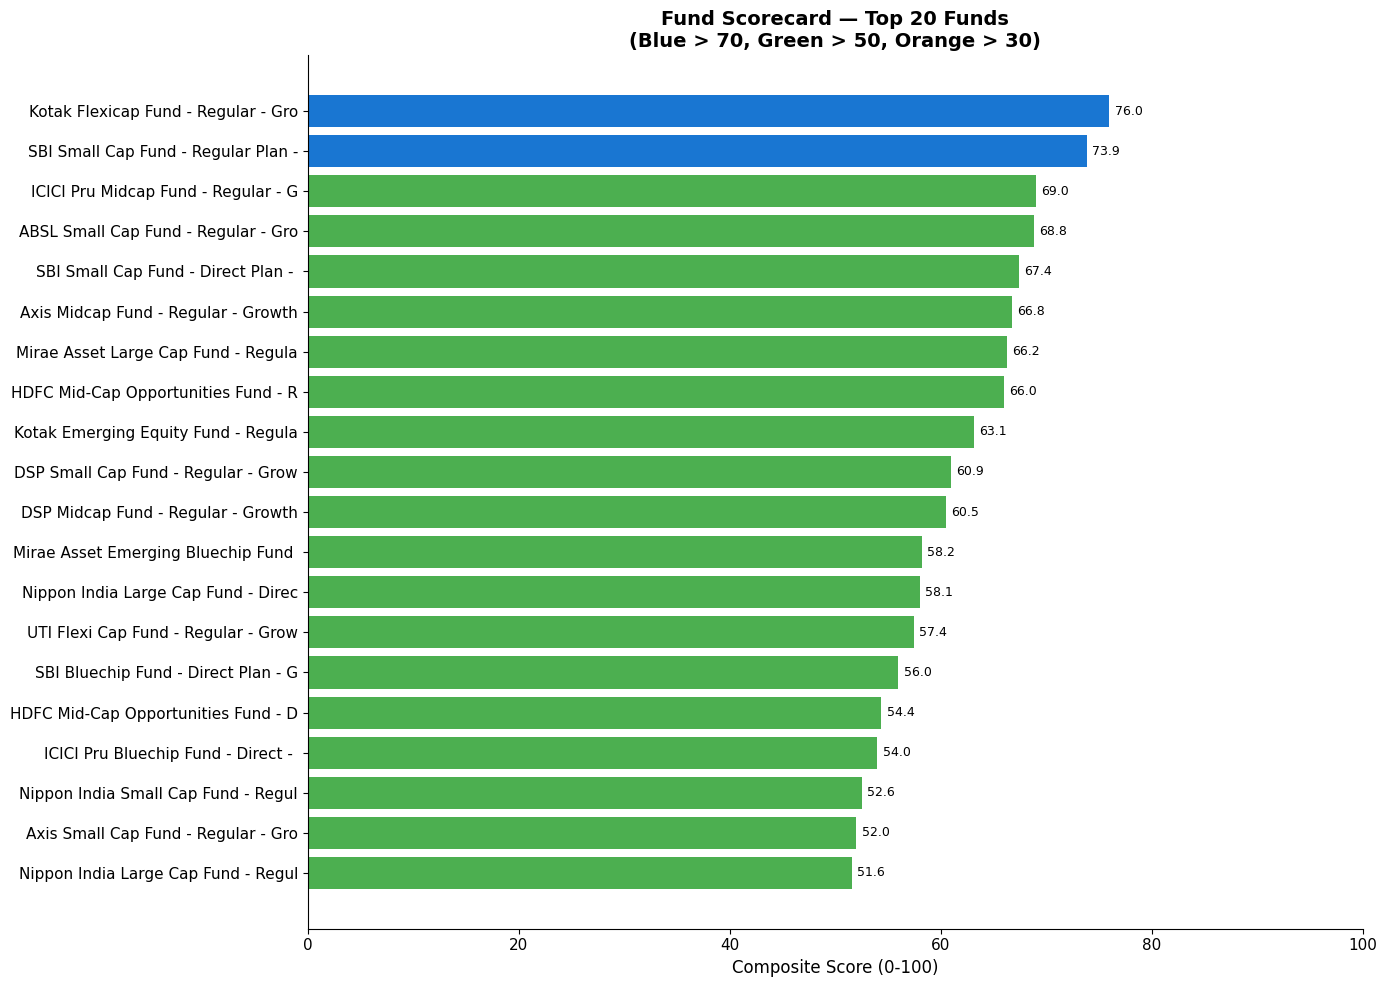

Chart saved: fund_scorecard.png
Saved: fund_scorecard.csv


In [10]:
# Cell 8 - Task 7: Build Fund Scorecard (composite score 0-100)
# We combine multiple metrics into one score to rank all 40 funds
# Score = 30% x 3yr return + 25% x Sharpe + 20% x Alpha
#       + 15% x Expense ratio (inverse) + 10% x Max DD (inverse)

print("Building Fund Scorecard...")
print("Composite Score = 30% x 3yr return rank")
print("               + 25% x Sharpe rank")
print("               + 20% x Alpha rank")
print("               + 15% x Expense ratio rank (lower is better)")
print("               + 10% x Max Drawdown rank (lower fall is better)\n")

# use pre-computed performance data for accurate 3yr returns and alpha
# our computed values had date alignment issues so we use the provided data
base = perf_df[["amfi_code", "scheme_name", "fund_house", "category",
                 "return_3yr_pct", "alpha", "expense_ratio_pct"]].copy()

# merge with our computed sharpe and max drawdown
base = base.merge(
    sharpe_df[["amfi_code", "sharpe_ratio"]],
    on="amfi_code", how="left"
)

base = base.merge(
    dd_df[["amfi_code", "max_drawdown_pct"]],
    on="amfi_code", how="left"
)

print(f"Funds in scorecard: {len(base)}")
print(f"Missing values: {base.isnull().sum().sum()}")

# fill any missing values with median
base["sharpe_ratio"]    = base["sharpe_ratio"].fillna(base["sharpe_ratio"].median())
base["max_drawdown_pct"]= base["max_drawdown_pct"].fillna(base["max_drawdown_pct"].median())

# RANKING
# rank() gives rank 1 to 40 for each metric
# pct=True converts to 0-1 scale (percentile rank)
# ascending=True  → higher value = higher rank (good for returns, sharpe, alpha)
# ascending=False → lower value = higher rank (good for expense ratio, drawdown)

# 3yr return rank - higher return = better rank
base["rank_return"] = base["return_3yr_pct"].rank(pct=True, ascending=True)

# sharpe rank - higher sharpe = better rank
base["rank_sharpe"] = base["sharpe_ratio"].rank(pct=True, ascending=True)

# alpha rank - higher alpha = better rank
base["rank_alpha"]  = base["alpha"].rank(pct=True, ascending=True)

# expense ratio rank - LOWER expense = BETTER rank (inverse)
base["rank_expense"] = base["expense_ratio_pct"].rank(pct=True, ascending=False)

# max drawdown rank - LESS negative = BETTER rank (inverse)
base["rank_drawdown"] = base["max_drawdown_pct"].rank(pct=True, ascending=False)

# COMPOSITE SCORE
# multiply each rank by its weight and sum up
# multiply by 100 to get score out of 100
base["composite_score"] = (
    0.30 * base["rank_return"]  +
    0.25 * base["rank_sharpe"]  +
    0.20 * base["rank_alpha"]   +
    0.15 * base["rank_expense"] +
    0.10 * base["rank_drawdown"]
) * 100

base["composite_score"] = base["composite_score"].round(2)

# final ranking
scorecard = base.sort_values("composite_score", ascending=False).reset_index(drop=True)
scorecard.index = scorecard.index + 1  # start rank from 1

print("\nFund Scorecard — Top 15 Funds:")
print(scorecard[["scheme_name", "composite_score", "return_3yr_pct",
                  "sharpe_ratio", "alpha", "expense_ratio_pct",
                  "max_drawdown_pct"]].head(15).to_string())

print("\nFund Scorecard — Bottom 5 Funds:")
print(scorecard[["scheme_name", "composite_score", "return_3yr_pct",
                  "sharpe_ratio", "alpha"]].tail(5).to_string())

# scorecard chart
fig, ax = plt.subplots(figsize=(14, 10))

colors = ["#1976D2" if s >= 70 else "#4CAF50" if s >= 50
          else "#FF9800" if s >= 30 else "#F44336"
          for s in scorecard["composite_score"].head(20)]

bars = ax.barh(
    scorecard["scheme_name"].head(20).str[:35],
    scorecard["composite_score"].head(20),
    color=colors
)

ax.set_xlabel("Composite Score (0-100)", fontsize=12)
ax.set_title("Fund Scorecard — Top 20 Funds\n(Blue > 70, Green > 50, Orange > 30)",
             fontsize=14, fontweight="bold")
ax.invert_yaxis()
ax.set_xlim(0, 100)

# add score labels
for bar, score in zip(bars, scorecard["composite_score"].head(20)):
    ax.text(score + 0.5, bar.get_y() + bar.get_height()/2,
            f"{score:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "fund_scorecard.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: fund_scorecard.png")

# save scorecard
scorecard_out = scorecard[["amfi_code", "scheme_name", "fund_house",
                            "category", "composite_score", "return_3yr_pct",
                            "sharpe_ratio", "alpha", "expense_ratio_pct",
                            "max_drawdown_pct"]].reset_index()
scorecard_out.columns = ["rank"] + list(scorecard_out.columns[1:])
out = os.path.join(OUTPUT_PATH, "fund_scorecard.csv")
scorecard_out.to_csv(out, index=False)
print(f"Saved: fund_scorecard.csv")

Building benchmark comparison chart...
Comparing top 5 funds vs Nifty 50 and Nifty 100



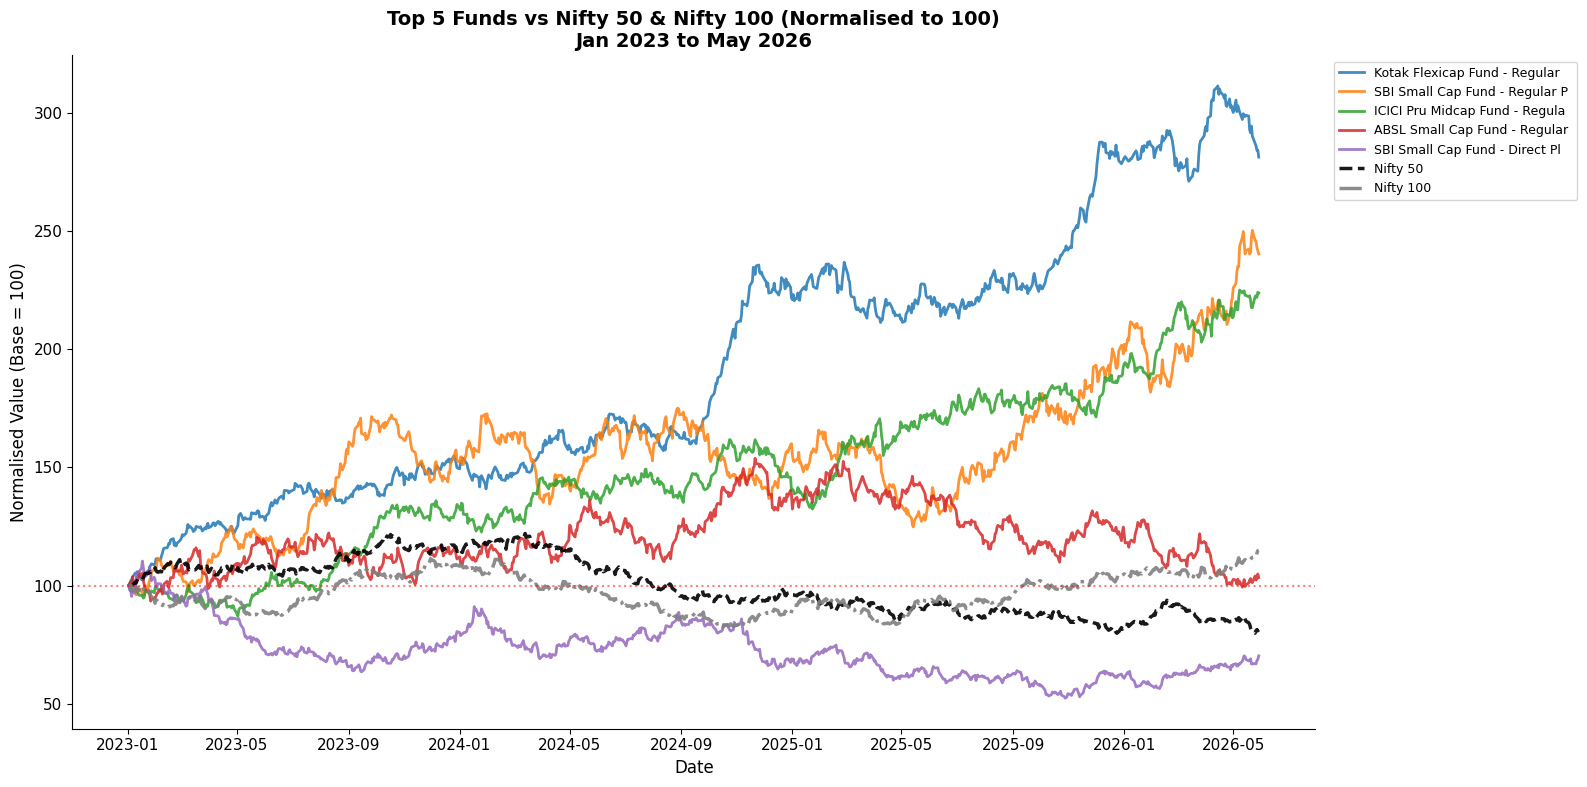

Chart saved: benchmark_chart.png

Tracking Error vs Nifty 100:
(Lower = fund moves more like the benchmark)
(Higher = fund deviates more from benchmark)

                        scheme_name  tracking_error
Kotak Flexicap Fund - Regular - Gro         20.6842
SBI Small Cap Fund - Regular Plan -         28.5817
ICICI Pru Midcap Fund - Regular - G         23.2110
ABSL Small Cap Fund - Regular - Gro         29.8008
SBI Small Cap Fund - Direct Plan -          27.3051

Day 4 Complete!
Files saved in data/processed/:
  returns_computed.csv
  cagr_report.csv
  sharpe_values.csv
  sortino_values.csv
  alpha_beta.csv
  max_drawdown.csv
  fund_scorecard.csv

Charts saved in reports/charts/:
  fund_scorecard.png
  benchmark_chart.png


In [13]:
# Cell 8 - Task 8: Benchmark comparison chart
# Plot top 5 funds vs Nifty 50 and Nifty 100 over 3 years
# Also compute tracking error for each fund

print("Building benchmark comparison chart...")
print("Comparing top 5 funds vs Nifty 50 and Nifty 100\n")

# get top 5 funds from scorecard
top5_codes = scorecard["amfi_code"].head(5).tolist()
top5_names = scorecard["scheme_name"].head(5).tolist()

# get Nifty 50 and Nifty 100 data
nifty50  = bench_df[bench_df["index_name"] == "NIFTY50"].sort_values("date").copy()
nifty100 = bench_df[bench_df["index_name"] == "NIFTY100"].sort_values("date").copy()

# filter to last 3 years only
# our data goes to May 2026 so 3 years back = May 2023
cutoff = pd.Timestamp("2023-01-01")
nifty50  = nifty50[nifty50["date"] >= cutoff]
nifty100 = nifty100[nifty100["date"] >= cutoff]

# normalise to 100 at start date so all lines start at same point
# this makes it easy to compare percentage growth
def normalise(series):
    series = pd.Series(series)
    return (series / series.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(16, 8))

# plot each top 5 fund
tracking_errors = []

for code, name in zip(top5_codes, top5_names):
    fund_data = nav_df[nav_df["amfi_code"] == code].sort_values("date")
    fund_data = fund_data[fund_data["date"] >= cutoff]

    if len(fund_data) < 10:
        continue

    # normalise NAV to 100
    nav_norm = normalise(fund_data["nav"].values)

    ax.plot(fund_data["date"].values, nav_norm,
            linewidth=2, label=name[:30], alpha=0.85)

    # compute tracking error vs Nifty 100
    # tracking error = std dev of (fund return - benchmark return)
    merged_te = fund_data[["date", "daily_return"]].merge(
        nifty100[["date", "close_value"]],
        on="date", how="inner"
    )

    if len(merged_te) > 10:
        bench_ret = merged_te["close_value"].pct_change().dropna()
        fund_ret  = merged_te["daily_return"].iloc[1:]
        min_len   = min(len(bench_ret), len(fund_ret))

        if min_len > 0:
            diff = fund_ret.values[:min_len] - bench_ret.values[:min_len]
            te   = np.std(diff) * np.sqrt(252) * 100
            tracking_errors.append({
                "scheme_name"    : name[:35],
                "tracking_error" : round(te, 4)
            })

# plot Nifty 50 and Nifty 100 as thick reference lines
nifty50_norm  = normalise(nifty50["close_value"].values)
nifty100_norm = normalise(nifty100["close_value"].values)

ax.plot(nifty50["date"].values, nifty50_norm,
        color="black", linewidth=2.5,
        linestyle="--", label="Nifty 50", alpha=0.9)

ax.plot(nifty100["date"].values, nifty100_norm,
        color="gray", linewidth=2.5,
        linestyle="-.", label="Nifty 100", alpha=0.9)

ax.set_title("Top 5 Funds vs Nifty 50 & Nifty 100 (Normalised to 100)\nJan 2023 to May 2026",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Normalised Value (Base = 100)", fontsize=12)
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=9)
ax.axhline(y=100, color="red", linestyle=":", alpha=0.5, label="Base = 100")

plt.tight_layout()
plt.savefig(os.path.join(CHART_PATH, "benchmark_chart.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: benchmark_chart.png")

# print tracking errors
print("\nTracking Error vs Nifty 100:")
print("(Lower = fund moves more like the benchmark)")
print("(Higher = fund deviates more from benchmark)\n")

te_df = pd.DataFrame(tracking_errors)
if len(te_df) > 0:
    print(te_df.to_string(index=False))

print("\nDay 4 Complete!")
print("Files saved in data/processed/:")
print("  returns_computed.csv")
print("  cagr_report.csv")
print("  sharpe_values.csv")
print("  sortino_values.csv")
print("  alpha_beta.csv")
print("  max_drawdown.csv")
print("  fund_scorecard.csv")
print("\nCharts saved in reports/charts/:")
print("  fund_scorecard.png")
print("  benchmark_chart.png")